# Training Deep Neural Networks — Exercises
## Week 6 — Day 1 | DI GenAI & Machine Learning Bootcamp 2026

**Exercises:**
- Exercise 1: Deep Learning vs Traditional Machine Learning
- Exercise 2: Artificial Neural Networks (ANNs)
- Exercise 3: Creating & Visualizing a Noisy Dataset
- Exercise 4: Fitting Polynomial Models (Overfitting)
- Exercise 5: Cross-Validation to Find Optimal Degree

## Exercise 1 — Deep Learning vs Traditional Machine Learning

### Comparison Table

| Feature | Traditional Machine Learning | Deep Learning |
|---|---|---|
| **Feature Engineering** | Manual — requires domain expertise to extract relevant features | Automatic — learns features directly from raw data |
| **Data Processing** | Works well with structured/tabular data | Excels on unstructured data (images, text, audio) |
| **Scalability** | Limited — performance plateaus with more data | Scales well — performance improves with more data |
| **Pattern Discovery** | Shallow patterns, requires explicit feature design | Hierarchical — discovers complex, abstract patterns |
| **Computational Requirements** | Low to medium — runs on CPU | High — requires GPU/TPU for training |

### Real-World Problem Comparison

**Where Traditional ML is better suited:**
> **Credit risk scoring** — The dataset is structured (income, age, credit history), the features are already meaningful, the dataset is relatively small (thousands of rows), and interpretability is legally required. A Logistic Regression or Random Forest model is faster to train, easier to explain to regulators, and performs just as well as a deep learning model.

**Where Deep Learning is the superior choice:**
> **Medical image diagnosis (e.g., detecting tumors in MRI scans)** — The input is raw pixel data (unstructured), the patterns are spatially complex and hierarchical (edges → textures → anatomical structures), and the dataset can be very large. A Convolutional Neural Network (CNN) automatically learns these spatial features with far greater accuracy than any hand-crafted feature approach.

### Why Deep Learning Excels at Unstructured Data

Deep learning has a fundamental advantage with unstructured data because it eliminates the bottleneck of manual feature engineering. In images, text, or audio, the meaningful patterns are not obvious to a human designer — they emerge from complex interactions between raw inputs. Deep neural networks, through their multiple layers of transformations, automatically discover hierarchical representations: for images, early layers detect edges and colors, middle layers identify shapes and textures, and deeper layers recognize objects and scenes. This end-to-end learning pipeline not only saves time but also discovers richer features than any human-crafted approach, which is why deep learning achieves superhuman performance on tasks like image recognition, speech synthesis, and natural language translation.

## Exercise 2 — Artificial Neural Networks (ANNs)

/var/folders/bm/prgjwvfs5xs9m_6qjbfk9mhw0000gn/T/ipykernel_4381/3504458925.py:34: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  circle = plt.Circle((x, y), neuron_radius, color=col, zorder=3, linewidth=2,


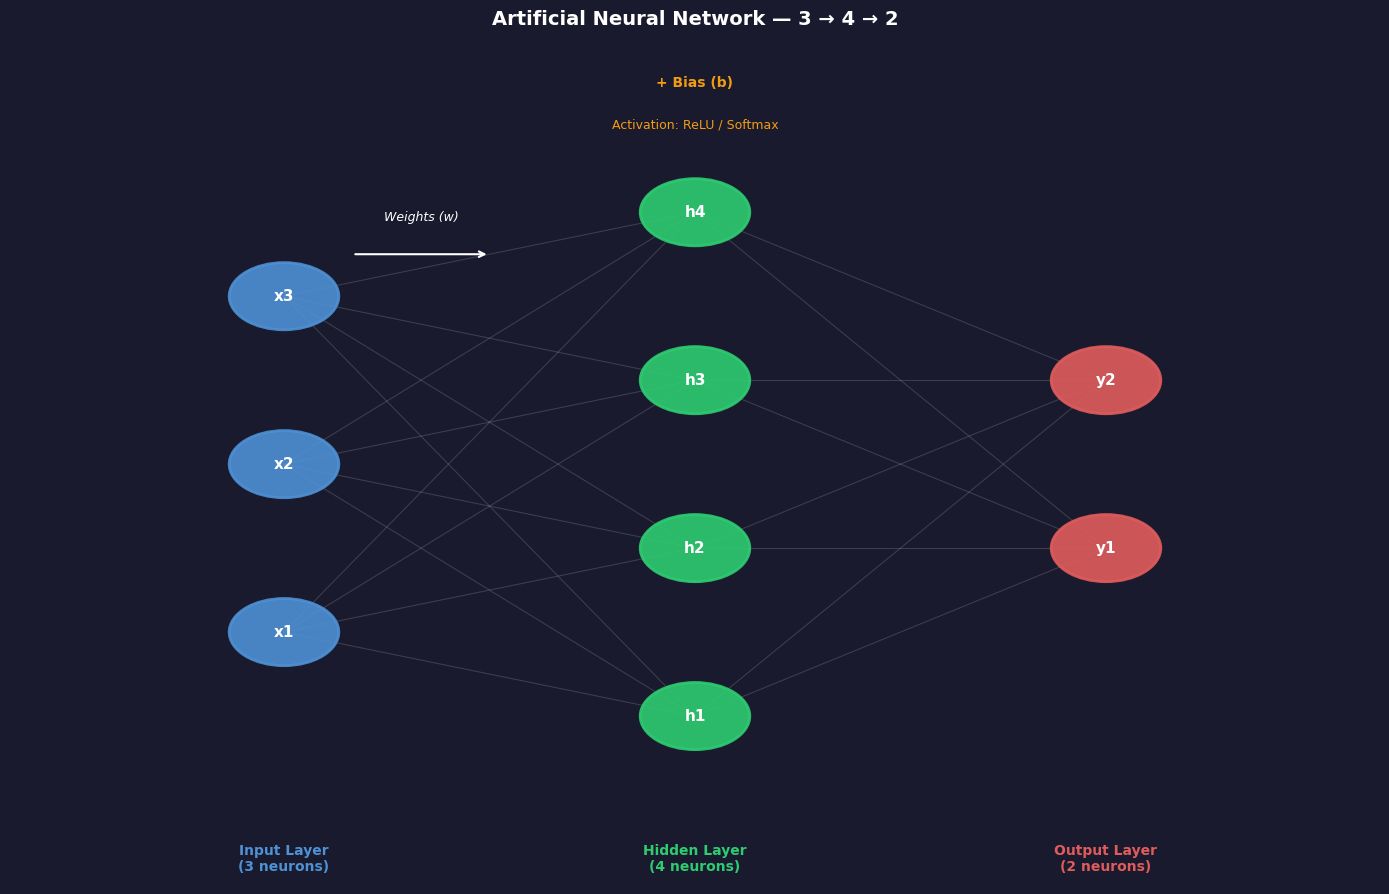

ANN diagram saved ✓


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

fig, ax = plt.subplots(figsize=(14, 9))
ax.set_xlim(0, 10); ax.set_ylim(0, 10)
ax.axis('off')
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')

layer_x   = [2, 5, 8]
layer_n   = [3, 4, 2]
layer_col = ['#4e91d4', '#2ecc71', '#e05c5c']
layer_lbl = ['Input Layer\n(3 neurons)', 'Hidden Layer\n(4 neurons)', 'Output Layer\n(2 neurons)']
neuron_radius = 0.4

# Calculate y positions for each layer
positions = []
for n in layer_n:
    start = (10 - (n - 1) * 2) / 2
    positions.append([start + i * 2 for i in range(n)])

# Draw connections (weights)
for l in range(len(layer_x) - 1):
    for i, y1 in enumerate(positions[l]):
        for j, y2 in enumerate(positions[l+1]):
            ax.plot([layer_x[l], layer_x[l+1]], [y1, y2],
                    color='white', alpha=0.15, lw=0.8, zorder=1)

# Draw neurons
for l, (x, ys, col) in enumerate(zip(layer_x, positions, layer_col)):
    for k, y in enumerate(ys):
        circle = plt.Circle((x, y), neuron_radius, color=col, zorder=3, linewidth=2,
                             edgecolor='white', alpha=0.9)
        ax.add_patch(circle)
        label = f'x{k+1}' if l == 0 else (f'h{k+1}' if l == 1 else f'y{k+1}')
        ax.text(x, y, label, ha='center', va='center', fontsize=11,
                color='white', fontweight='bold', zorder=4)
    # Layer label
    ax.text(x, 0.3, layer_lbl[l], ha='center', va='center', fontsize=10,
            color=col, fontweight='bold', zorder=4)

# Annotations
ax.annotate('', xy=(3.5, 7.5), xytext=(2.5, 7.5),
            arrowprops=dict(arrowstyle='->', color='white', lw=1.5))
ax.text(3.0, 7.9, 'Weights (w)', ha='center', color='white', fontsize=9, style='italic')

ax.text(5, 9.5, '+ Bias (b)', ha='center', color='#f39c12', fontsize=10, fontweight='bold')
ax.text(5, 9.0, 'Activation: ReLU / Softmax', ha='center', color='#f39c12', fontsize=9)

# Title
ax.text(5, 10.3, 'Artificial Neural Network — 3 → 4 → 2',
        ha='center', va='center', fontsize=14, color='white', fontweight='bold',
        transform=ax.transData)

plt.tight_layout()
plt.savefig('ann_diagram.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print("ANN diagram saved ✓")

### ANN Components Description

**How information flows through the network:**

1. **Input Layer (3 neurons):** Each neuron receives one raw feature value (x₁, x₂, x₃). No computation happens here — it simply passes data to the next layer.

2. **Hidden Layer (4 neurons):** Each neuron computes a **weighted sum** of all inputs: `z = w₁x₁ + w₂x₂ + w₃x₃ + b`, then applies an **activation function** (e.g., ReLU) to introduce non-linearity: `h = ReLU(z)`. The weights (w) control how much each input matters; the bias (b) shifts the activation threshold.

3. **Output Layer (2 neurons):** Each output neuron computes a weighted sum of the hidden layer activations and applies a final activation (e.g., Softmax for classification) to produce the final prediction (y₁, y₂).

4. **Backpropagation:** After a prediction, the loss is computed and gradients flow **backward** through the network, adjusting all weights and biases to minimize the error on the next forward pass.

## Exercise 3 — Creating the Dataset and Visualizing the Data

Dataset: 20 points
x range: [-1.0, 0.9]
y range: [-0.912, 0.063]

Training set: 12 points (x from -1.0 to 0.1)
Test set:     8 points  (x from 0.2  to 0.9)


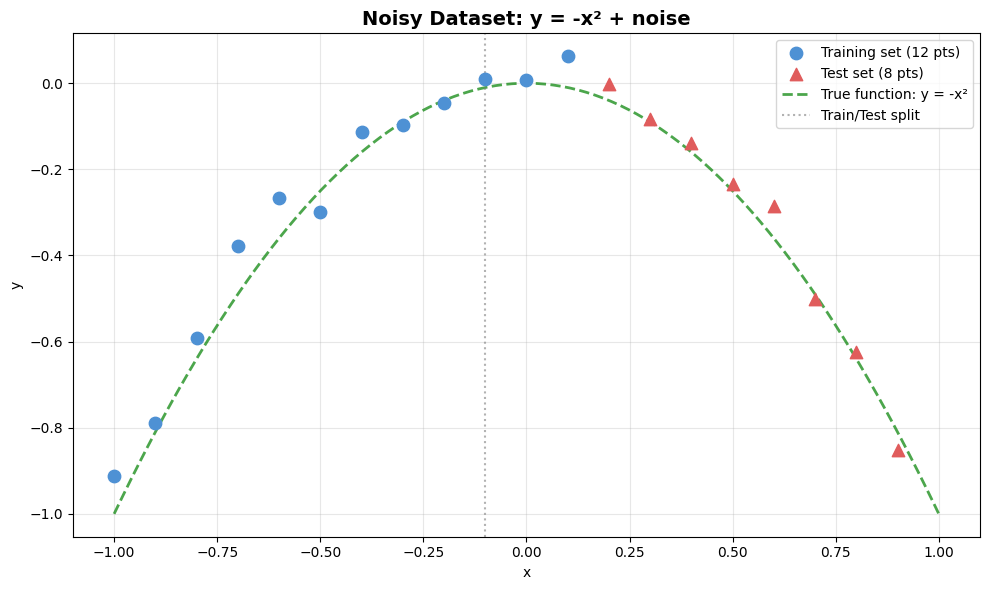

Plot saved ✓


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Step 1 — Generate noisy dataset: y = -x² + noise
np.random.seed(0)
x = np.arange(-1, 1, 0.1)
y = -x**2 + np.random.normal(0, 0.05, len(x))

print(f"Dataset: {len(x)} points")
print(f"x range: [{x.min():.1f}, {x.max():.1f}]")
print(f"y range: [{y.min():.3f}, {y.max():.3f}]")

# Step 2 — Split: first 12 = train, last 8 = test
x_train, y_train = x[:12], y[:12]
x_test,  y_test  = x[12:], y[12:]

print(f"\nTraining set: {len(x_train)} points (x from {x_train[0]:.1f} to {x_train[-1]:.1f})")
print(f"Test set:     {len(x_test)} points  (x from {x_test[0]:.1f}  to {x_test[-1]:.1f})")

# Step 3 — Scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(x_train, y_train, color='#4e91d4', s=80, zorder=5, label='Training set (12 pts)')
plt.scatter(x_test,  y_test,  color='#e05c5c', s=80, zorder=5, marker='^', label='Test set (8 pts)')

x_true = np.linspace(-1, 1, 200)
plt.plot(x_true, -x_true**2, 'g--', lw=2, label='True function: y = -x²', alpha=0.7)

plt.axvline(x=-0.1, color='gray', linestyle=':', lw=1.5, alpha=0.6, label='Train/Test split')
plt.title('Noisy Dataset: y = -x² + noise', fontsize=14, fontweight='bold')
plt.xlabel('x'); plt.ylabel('y')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ex3_dataset.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved ✓")

## Exercise 4 — Fitting Polynomial Models of Different Degrees

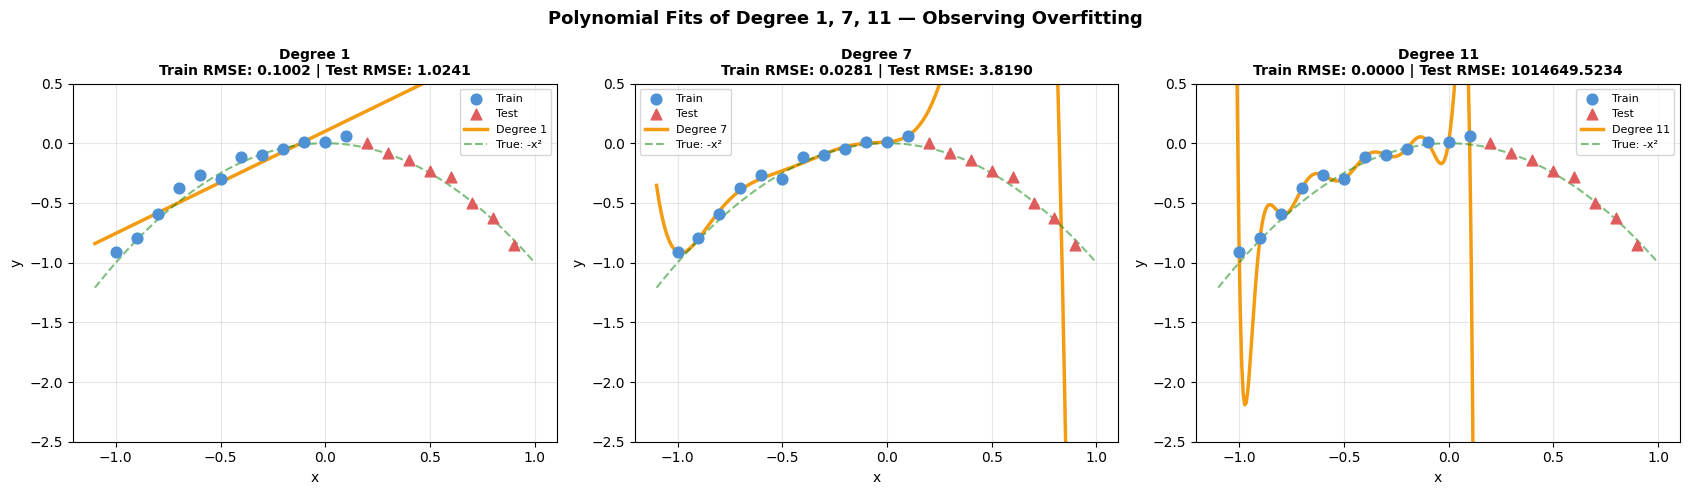

Plot saved ✓

Observations:
  Degree 1  → UNDERFITTING: the line can't capture the parabolic shape.
  Degree 7  → GOOD FIT: flexible enough to follow the curve without memorizing noise.
  Degree 11 → OVERFITTING: fits the training points exactly but explodes on the test set.



In [3]:
def polynomial_fit(degree):
    """Fit a polynomial of given degree to the training data. Returns the polynomial."""
    coeffs = np.polyfit(x_train, y_train, degree)
    return np.poly1d(coeffs)

def plot_polyfit(degree, ax):
    """Plot training set, test set, and fitted polynomial curve for a given degree."""
    poly = polynomial_fit(degree)
    x_plot = np.linspace(x.min() - 0.1, x.max() + 0.1, 300)

    train_rmse = np.sqrt(mean_squared_error(y_train, poly(x_train)))
    test_rmse  = np.sqrt(mean_squared_error(y_test,  poly(x_test)))

    ax.scatter(x_train, y_train, color='#4e91d4', s=60, zorder=5, label='Train')
    ax.scatter(x_test,  y_test,  color='#e05c5c', s=60, zorder=5, marker='^', label='Test')
    ax.plot(x_plot, poly(x_plot), color='#f39c12', lw=2.5, label=f'Degree {degree}')
    ax.plot(x_plot, -x_plot**2, 'g--', lw=1.5, alpha=0.5, label='True: -x²')
    ax.set_ylim(-2.5, 0.5)
    ax.set_title(f'Degree {degree}\nTrain RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f}',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Visualize degrees 1, 7, and 11
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, deg in zip(axes, [1, 7, 11]):
    plot_polyfit(deg, ax)

plt.suptitle('Polynomial Fits of Degree 1, 7, 11 — Observing Overfitting',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('ex4_polynomial_fits.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved ✓")

print("""
Observations:
  Degree 1  → UNDERFITTING: the line can't capture the parabolic shape.
  Degree 7  → GOOD FIT: flexible enough to follow the curve without memorizing noise.
  Degree 11 → OVERFITTING: fits the training points exactly but explodes on the test set.
""")

## Exercise 5 — Cross-Validation to Find the Optimal Degree

In [4]:
# Loop through polynomial degrees 1 to 11
cv_results = []

print(f"{'Degree':<8} {'Train RMSE':<14} {'Test RMSE'}")
print("-" * 38)

for degree in range(1, 12):
    poly = polynomial_fit(degree)
    train_rmse = np.sqrt(mean_squared_error(y_train, poly(x_train)))
    test_rmse  = np.sqrt(mean_squared_error(y_test,  poly(x_test)))
    cv_results.append({'degree': degree, 'train_rmse': train_rmse, 'test_rmse': test_rmse})
    print(f"  {degree:<6} {train_rmse:<14.6f} {test_rmse:.6f}")

# Best degree = minimizes test RMSE
best = min(cv_results, key=lambda r: r['test_rmse'])
print(f"\nBest degree: {best['degree']} (Test RMSE = {best['test_rmse']:.6f})")
print(f"→ Degree {best['degree']} corresponds to the true underlying model y = -x² ✓")

Degree   Train RMSE     Test RMSE
--------------------------------------
  1      0.100226       1.024071
  2      0.041146       0.125781
  3      0.037337       0.769652
  4      0.036838       1.700233
  5      0.034942       6.206938
  6      0.028372       58.827475
  7      0.028134       3.819049
  8      0.027556       523.816993
  9      0.020865       10165.845299
  10     0.020599       25560.431512
  11     0.000000       1014649.523434

Best degree: 2 (Test RMSE = 0.125781)
→ Degree 2 corresponds to the true underlying model y = -x² ✓


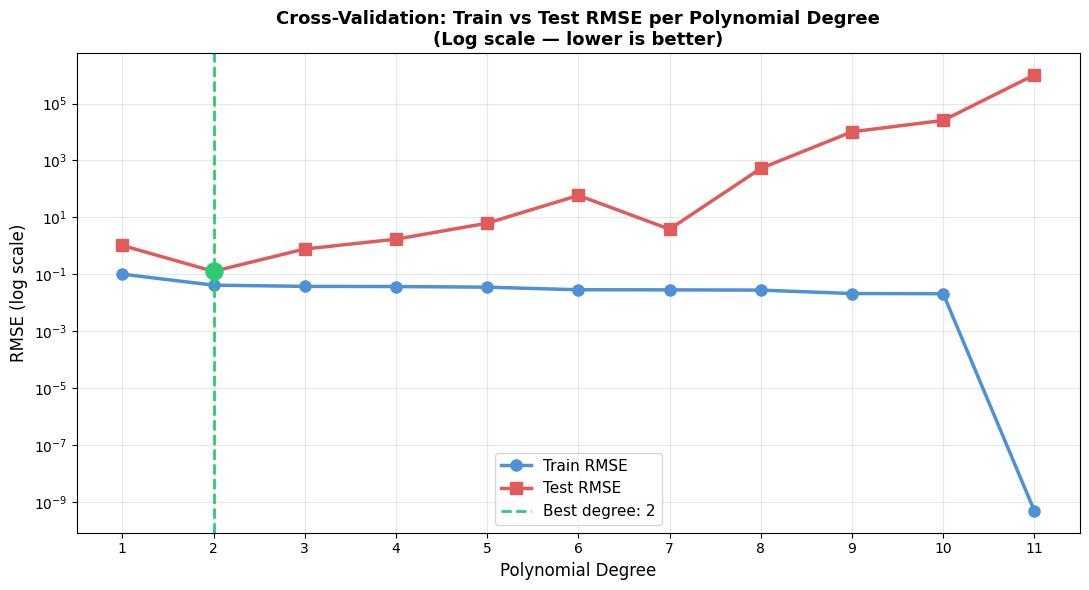


Conclusion:
  - As degree increases: Train RMSE decreases monotonically (model memorizes data)
  - Test RMSE reaches a minimum at degree 2 then increases (overfitting)
  - Degree 2 matches the true model y = -x² — cross-validation recovers it ✓
  - This demonstrates the Bias-Variance tradeoff:
      Low degree → High bias (underfitting)
      High degree → High variance (overfitting)
      Optimal degree → Balanced bias & variance

Plot saved ✓


In [5]:
# Plot RMSE vs Degree (log scale)
degrees     = [r['degree']    for r in cv_results]
train_rmses = [r['train_rmse'] for r in cv_results]
test_rmses  = [r['test_rmse']  for r in cv_results]

plt.figure(figsize=(11, 6))
plt.plot(degrees, train_rmses, 'o-', color='#4e91d4', lw=2.5, markersize=8, label='Train RMSE')
plt.plot(degrees, test_rmses,  's-', color='#e05c5c', lw=2.5, markersize=8, label='Test RMSE')

# Mark the best degree
plt.axvline(x=best['degree'], color='#2ecc71', linestyle='--', lw=2,
            label=f"Best degree: {best['degree']}")
plt.scatter([best['degree']], [best['test_rmse']], color='#2ecc71', s=150, zorder=6)

plt.yscale('log')
plt.xticks(degrees)
plt.xlabel('Polynomial Degree', fontsize=12)
plt.ylabel('RMSE (log scale)', fontsize=12)
plt.title('Cross-Validation: Train vs Test RMSE per Polynomial Degree\n'
          '(Log scale — lower is better)', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('ex5_cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"""
Conclusion:
  - As degree increases: Train RMSE decreases monotonically (model memorizes data)
  - Test RMSE reaches a minimum at degree {best['degree']} then increases (overfitting)
  - Degree {best['degree']} matches the true model y = -x² — cross-validation recovers it ✓
  - This demonstrates the Bias-Variance tradeoff:
      Low degree → High bias (underfitting)
      High degree → High variance (overfitting)
      Optimal degree → Balanced bias & variance
""")
print("Plot saved ✓")